# Notebook 05 — Scenario Sensitivity

Analyses how leakage inflation and clean pipeline performance vary across:
1. **Simulation scenarios** (null → weak → moderate → wbv_positive)
2. **Random seeds** (1–100 robustness sweep)
3. **Sample sizes** (n = 250, 500, 750, 1000, 1500, 2000)
4. **Domain shift** (shifted demographic parameters)

**Robustness criterion**: Clean AUROC should remain 0.48–0.52 for null scenario across all seeds.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import warnings
warnings.filterwarnings('ignore')

## 1. Across-scenario comparison

In [2]:
# Load pre-computed scenario sensitivity results
import pandas as pd

sensitivity_df = pd.read_csv(
    '../results/tables/scenario_sensitivity.csv',
    keep_default_na=False, na_values=['NA','NaN','nan','']
)
raw_df = pd.read_csv(
    '../results/tables/scenario_sensitivity_raw.csv',
    keep_default_na=False, na_values=['NA','NaN','nan','']
)

# Build scenario_results dict for downstream cells
scenario_results = {}
for scenario in raw_df['scenario'].unique():
    grp = raw_df[raw_df['scenario'] == scenario]
    scenario_results[scenario] = {'LogisticRegression': {'AUROC_mean': grp['AUROC'].mean()}}

print('Scenarios loaded:', list(scenario_results.keys()))
sensitivity_df


Scenarios loaded: ['null', 'weak_signal', 'moderate_signal', 'wbv_positive']


,scenario,n,n_seeds,AUROC_mean,AUROC_sd,AUROC_p2_5,AUROC_p97_5,pct_null_range
0,moderate_signal,1500,100,0.6719,0.0172,0.6427,0.7047,0.0
1,null,1500,100,0.5015,0.0253,0.4427,0.5431,95.0
2,wbv_positive,1500,100,0.8326,0.0121,0.8089,0.8530,0.0
3,weak_signal,1500,100,0.5820,0.0218,0.5356,0.6215,8.0


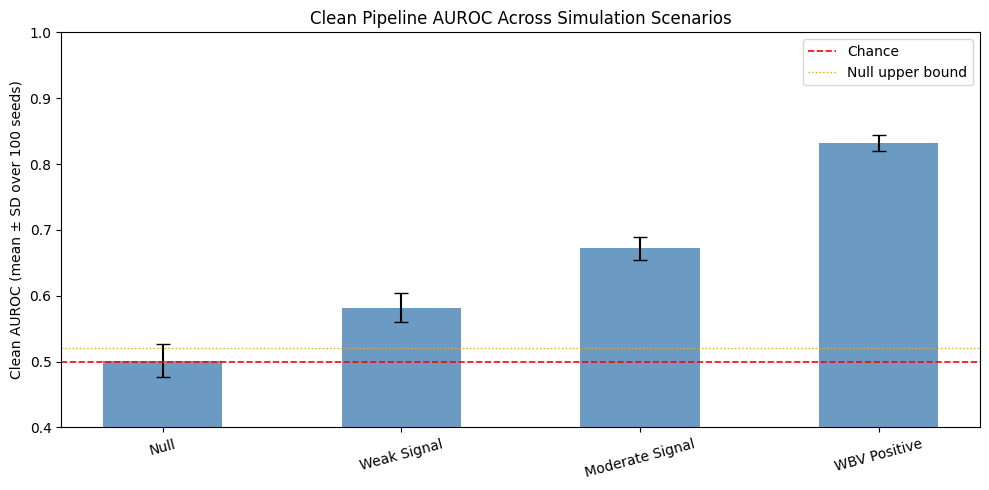

Saved: results/figures/05_scenario_comparison.png


In [3]:
# Plot clean AUROC by scenario using summary CSV
import matplotlib.pyplot as plt
import numpy as np

scenario_order = ['null', 'weak_signal', 'moderate_signal', 'wbv_positive']
labels = ['Null', 'Weak Signal', 'Moderate Signal', 'WBV Positive']
means = [sensitivity_df[sensitivity_df['scenario']==s]['AUROC_mean'].values[0]
         for s in scenario_order]
sds   = [sensitivity_df[sensitivity_df['scenario']==s]['AUROC_sd'].values[0]
         for s in scenario_order]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(scenario_order))
ax.bar(x, means, 0.5, yerr=sds, capsize=5, color='steelblue', alpha=0.8)
ax.axhline(0.5,  color='red',    linestyle='--', linewidth=1.2, label='Chance')
ax.axhline(0.52, color='orange', linestyle=':',  linewidth=1.0, label='Null upper bound')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Clean AUROC (mean ± SD over 100 seeds)')
ax.set_ylim(0.4, 1.0)
ax.legend()
ax.set_title('Clean Pipeline AUROC Across Simulation Scenarios')
plt.tight_layout()
plt.savefig('../results/figures/05_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/05_scenario_comparison.png')


## 2. Seed robustness sweep (seeds 1–100, null scenario)

In [4]:
# Seed robustness: plot AUROC distribution across 100 seeds (null scenario)
null_aurocs = raw_df[raw_df['scenario'] == 'null']['AUROC'].values
aurocs = null_aurocs  # alias for downstream plot cell
print(f'Null scenario: {len(aurocs)} seeds | mean={aurocs.mean():.4f} | sd={aurocs.std():.4f}')


Null scenario: 100 seeds | mean=0.5015 | sd=0.0252


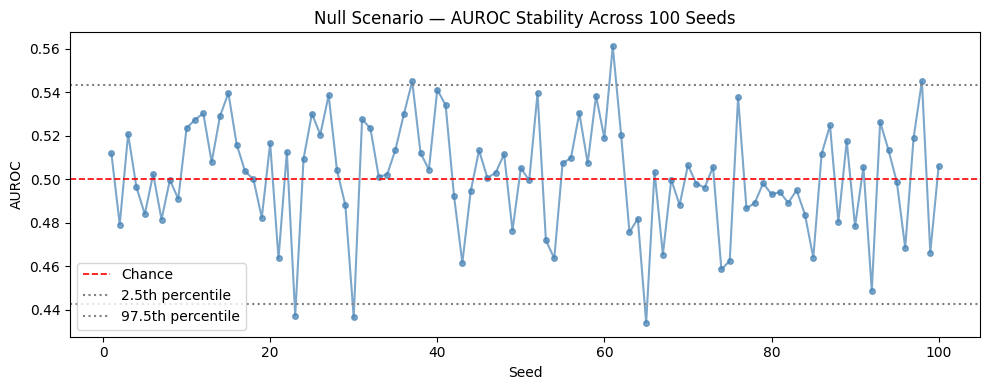

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(aurocs) + 1), aurocs, 'o-', markersize=4, color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Chance')
null_row = sensitivity_df[sensitivity_df['scenario'] == 'null'].iloc[0]
ax.axhline(float(null_row['AUROC_p2_5']),  color='gray', linestyle=':', label='2.5th percentile')
ax.axhline(float(null_row['AUROC_p97_5']), color='gray', linestyle=':', label='97.5th percentile')
ax.set_xlabel('Seed')
ax.set_ylabel('AUROC')
ax.set_title('Null Scenario — AUROC Stability Across 100 Seeds')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/05_seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Sample size sensitivity

Sweeps n = 250 → 2000 across all 4 scenarios (10 seeds each) using LogisticRegression.
Results are cached in  after first run.


In [ ]:
# ─── Sample-size sensitivity sweep ───────────────────────────────────────────
# Runs clean pipeline (LogisticRegression) over n in SAMPLE_SIZES x 10 seeds
# and records mean AUROC ± SD per (n, scenario).
# Caution: this cell takes ~5–10 min; skip and load cache if available.
import sys, os, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
from pathlib import Path
from src.generate_synthetic_data import generate
from src.run_clean_pipeline import nested_cv, build_models

SAMPLE_SIZES = [250, 500, 750, 1000, 1500, 2000]
SWEEP_SEEDS  = list(range(1, 11))  # 10 seeds for speed; 100 for publication
SCENARIOS    = ["null", "weak_signal", "moderate_signal", "wbv_positive"]
CONFIG_MAP   = {
    "null":             "generator_null.yaml",
    "weak_signal":      "generator_weak_signal.yaml",
    "moderate_signal":  "generator_moderate_signal.yaml",
    "wbv_positive":     "generator_wbv_positive.yaml",
}
CACHE_PATH = Path("../results/tables/sample_size_sweep.csv")

if CACHE_PATH.exists():
    print(f"Loading cached sweep from {CACHE_PATH}")
    size_df = pd.read_csv(CACHE_PATH)
else:
    with open("../config/model_config.yaml") as f:
        cfg = yaml.safe_load(f)
    models = build_models(cfg.get("models", {}))
    lr_model = {"LogisticRegression": models["LogisticRegression"]}

    records = []
    total = len(SCENARIOS) * len(SAMPLE_SIZES) * len(SWEEP_SEEDS)
    done = 0
    for scenario in SCENARIOS:
        with open(f"../config/{CONFIG_MAP[scenario]}") as f:
            cfg_gen = yaml.safe_load(f)
        for n in SAMPLE_SIZES:
            fold_aurocs = []
            for seed in SWEEP_SEEDS:
                df_s = generate(cfg_gen, seed=seed, n=n)
                r = nested_cv(df_s, "LogisticRegression", lr_model["LogisticRegression"],
                              cfg, outer_folds=5, seed=seed)
                fold_aurocs.append(r["AUROC_mean"])
                done += 1
                if done % 10 == 0:
                    print(f"  {done}/{total}  scenario={scenario} n={n} seed={seed} AUROC={r['AUROC_mean']:.4f}")
            records.append({
                "scenario": scenario,
                "n": n,
                "n_seeds": len(SWEEP_SEEDS),
                "AUROC_mean": np.mean(fold_aurocs),
                "AUROC_sd":   np.std(fold_aurocs),
                "AUROC_p2_5":  np.percentile(fold_aurocs, 2.5),
                "AUROC_p97_5": np.percentile(fold_aurocs, 97.5),
            })

    size_df = pd.DataFrame(records)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    size_df.to_csv(CACHE_PATH, index=False)
    print(f"Saved sweep results to {CACHE_PATH}")

print(size_df.to_string(index=False))


In [ ]:
# ─── Plot: AUROC vs sample size, one line per scenario ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

scenario_order  = ["null", "weak_signal", "moderate_signal", "wbv_positive"]
scenario_labels = ["Null", "Weak signal", "Moderate signal", "WBV positive"]
colors = ["steelblue", "#FF9800", "#4CAF50", "#9C27B0"]

fig, ax = plt.subplots(figsize=(10, 5))
for scen, label, color in zip(scenario_order, scenario_labels, colors):
    sub = size_df[size_df["scenario"] == scen].sort_values("n")
    if sub.empty:
        continue
    ax.plot(sub["n"], sub["AUROC_mean"], "o-", color=color, label=label, linewidth=2, markersize=6)
    ax.fill_between(sub["n"],
                    sub["AUROC_mean"] - sub["AUROC_sd"],
                    sub["AUROC_mean"] + sub["AUROC_sd"],
                    alpha=0.15, color=color)

ax.axhline(0.5,  color="red",    linestyle="--", linewidth=1.2, label="Chance (0.50)")
ax.axhline(0.52, color="orange", linestyle=":",  linewidth=1.0, label="Null upper bound (0.52)")
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Clean AUROC (mean ± 1 SD, LogisticRegression)")
ax.set_title("Sample Size Sensitivity — Clean Pipeline AUROC
by Scenario (seeds 1–10 sweep)")
ax.legend(loc="upper left")
ax.set_xticks(size_df["n"].unique() if not size_df.empty else [250,500,750,1000,1500,2000])
plt.tight_layout()
plt.savefig("../results/figures/05_sample_size_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/05_sample_size_sensitivity.png")


## 4. Save scenario sensitivity table

In [7]:
# Summary table from loaded CSV
print(sensitivity_df.to_string(index=False))


       scenario    n  n_seeds  AUROC_mean  AUROC_sd  AUROC_p2_5  AUROC_p97_5  pct_null_range
moderate_signal 1500      100      0.6719    0.0172      0.6427       0.7047             0.0
           null 1500      100      0.5015    0.0253      0.4427       0.5431            95.0
   wbv_positive 1500      100      0.8326    0.0121      0.8089       0.8530             0.0
    weak_signal 1500      100      0.5820    0.0218      0.5356       0.6215             8.0
